In [15]:
!pip install seaborn

In [88]:
import requests
import json
import pprint
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/74.0.3729.169 YaBrowser/19.6.1.153 Yowser/2.5 Safari/537.36'}

In [99]:
df = pd.read_csv("tyler_holders_expanded.csv")
len(df)

200

In [34]:
df.drop(columns="Unnamed: 0", inplace=True)

In [9]:
df_scatter = df.drop(columns=["wallet", "market", "yes_no_index", "pseudonym", "username", "profit"])

In [19]:
df_scatter

,side,shares
0,NO,10000.0
1,YES,7357.0
2,YES,6141.0
3,NO,5734.0
4,YES,4881.0
...,...,...
195,YES,3.0
196,YES,3.0
197,NO,3.0
198,NO,3.0


C:\Users\arvid\AppData\Local\Temp\ipykernel_68712\3570979236.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
C:\Users\arvid\.venvs\lede\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


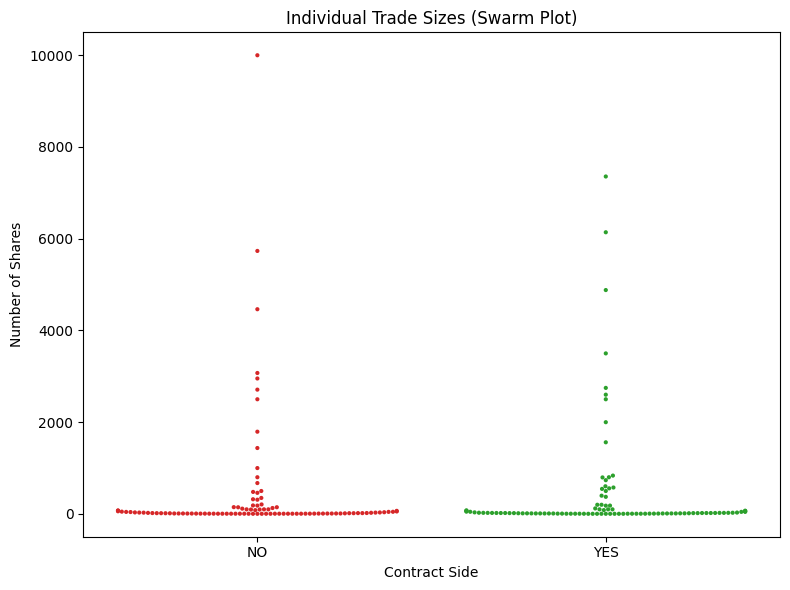

In [20]:
plt.figure(figsize=(8, 6))

# 3. Generate the swarm plot
# We map YES to green and NO to red for intuitive reading
sns.swarmplot(
    data=df_scatter, 
    x='side', 
    y='shares', 
    palette={'YES': '#2ca02c', 'NO': '#d62728'},
    size=3  # Adjust this depending on how many rows you have
)

# 4. Add labels and title
plt.title('Individual Trade Sizes (Swarm Plot)')
plt.xlabel('Contract Side')
plt.ylabel('Number of Shares')

# 5. Clean up layout and display
plt.tight_layout()
plt.show()

C:\Users\arvid\AppData\Local\Temp\ipykernel_68712\2043379797.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


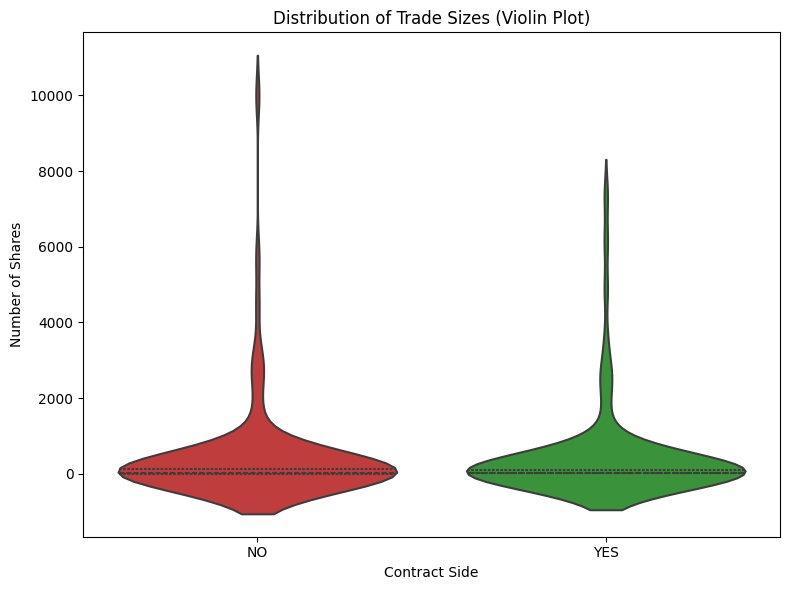

In [21]:
plt.figure(figsize=(8, 6))

# 3. Generate the violin plot
# inner='quartile' draws dotted lines inside the violin at the 25th, 50th, and 75th percentiles
sns.violinplot(
    data=df_scatter, 
    x='side', 
    y='shares', 
    palette={'YES': '#2ca02c', 'NO': '#d62728'},
    inner='quartile',
    linewidth=1.5
)

# 4. Add labels and title
plt.title('Distribution of Trade Sizes (Violin Plot)')
plt.xlabel('Contract Side')
plt.ylabel('Number of Shares')

# 5. Clean up layout and display
plt.tight_layout()
plt.show()

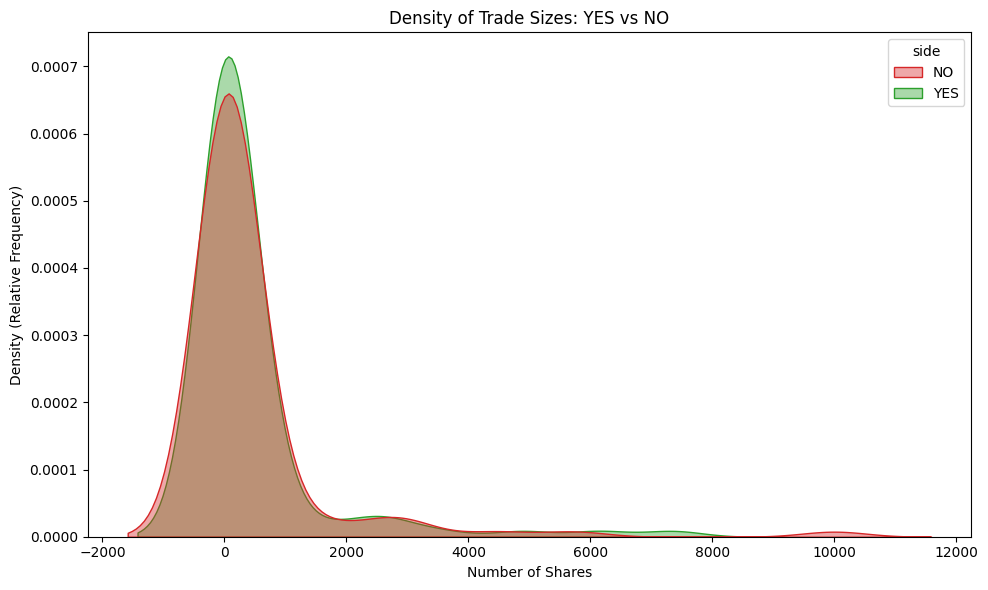

In [23]:
plt.figure(figsize=(10, 6))

# 3. Generate the overlapping KDE (Kernel Density Estimate) plot
# common_norm=False ensures both curves are scaled independently. 
# Without it, if there are 10x more YES trades than NO trades, the NO curve would look completely flat.
sns.kdeplot(
    data=df_scatter, 
    x='shares', 
    hue='side', 
    fill=True, 
    alpha=0.4, 
    palette={'YES': '#2ca02c', 'NO': '#d62728'},
    common_norm=False
)

# 4. Add labels and title
plt.title('Density of Trade Sizes: YES vs NO')
plt.xlabel('Number of Shares')
plt.ylabel('Density (Relative Frequency)')

# 5. Clean up layout and display
plt.tight_layout()
plt.show()

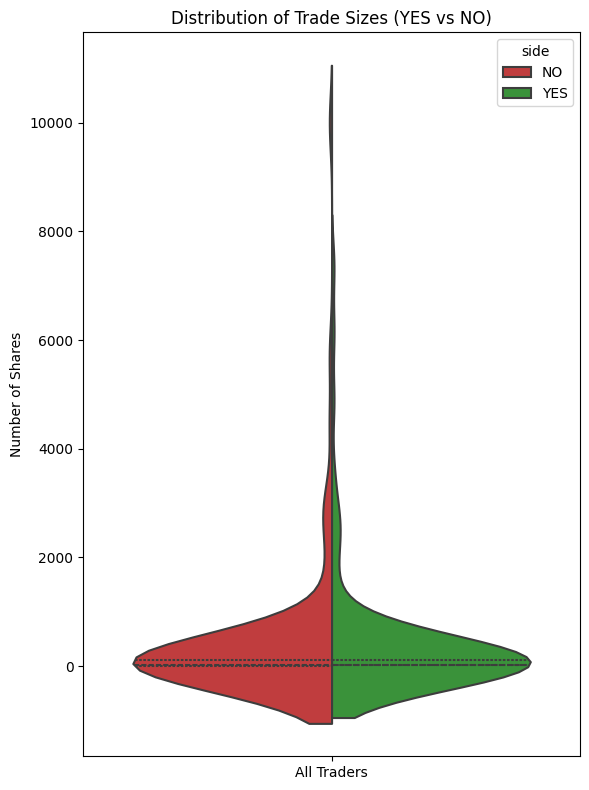

In [61]:
df_scatter['Trade Group'] = 'All Traders'

# 3. Set up the plotting canvas
plt.figure(figsize=(6, 8))

# 4. Generate the split violin plot
sns.violinplot(
    data=df_scatter,
    x='Trade Group',    # All data goes into this one bucket
    y='shares',         # The continuous variable
    hue='side',         # The binary variable to split by
    split=True,         # This parameter splits the violin down the middle
    inner='quartile',   # Optional: draws quartile lines inside the violin
    palette={'YES': '#2ca02c', 'NO': '#d62728'},
    linewidth=1.5
)

# 5. Clean up labels
plt.title('Distribution of Trade Sizes (YES vs NO)')
plt.xlabel('')          # We remove the X label since "All Trades" is self-explanatory
plt.ylabel('Number of Shares')

#save it
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('violin_share_distr.svg', format='svg', bbox_inches='tight')

# 6. Display the plot
plt.tight_layout()
plt.show()

In [26]:
df_scatter.to_csv("violin_plot_traders_vs_shares.csv")

In [48]:
df_scatter.groupby("side")["shares"].mean()

side
NO     426.05
YES    426.30
Name: shares, dtype: float64

In [36]:
df_trader_profit = df_scatter.join(df["profit"])
df_trader_profit

,side,shares,Trade Group,profit
0,NO,10000.0,All Traders,5519.377114
1,YES,7357.0,All Traders,15081.368235
2,YES,6141.0,All Traders,10147.723216
3,NO,5734.0,All Traders,1327.460662
4,YES,4881.0,All Traders,20020.766643
...,...,...,...,...
195,YES,3.0,All Traders,-32.556677
196,YES,3.0,All Traders,-27.851524
197,NO,3.0,All Traders,-151.778106
198,NO,3.0,All Traders,-9.752003


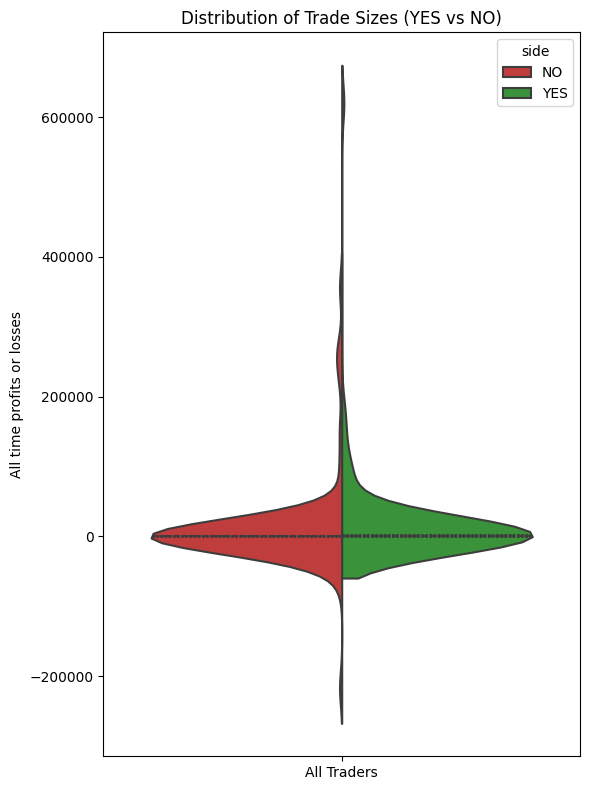

In [62]:
df_trader_profit['Trade Group'] = 'All Traders'

# 3. Set up the plotting canvas
plt.figure(figsize=(6, 8))

# 4. Generate the split violin plot
sns.violinplot(
    data=df_trader_profit,
    x='Trade Group',    # All data goes into this one bucket
    y='profit',         # The continuous variable
    hue='side',         # The binary variable to split by
    split=True,         # This parameter splits the violin down the middle
    inner='quartile',   # Optional: draws quartile lines inside the violin
    palette={'YES': '#2ca02c', 'NO': '#d62728'},
    linewidth=1.5
)

# 5. Clean up labels
plt.title('Distribution of Trade Sizes (YES vs NO)')
plt.xlabel('')          # We remove the X label since "All Trades" is self-explanatory
plt.ylabel('All time profits or losses')

plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('violin_profit_distr.svg', format='svg', bbox_inches='tight')

# 6. Display the plot
plt.tight_layout()
plt.show()

In [49]:
df_trader_profit.groupby("side")["profit"].mean()

side
NO     10963.049996
YES    16720.072898
Name: profit, dtype: float64

In [58]:
#How much more profit do the yay-sayers have compared to the nay?
print(f"The yes-bettors on average have made {round((16720 / 10963 - 1) * 100)} percent more profit than the nay bettors, in their polymarket careers.")

The yes-bettors on average have made 53 percent more profit than the nay bettors, in their polymarket careers.


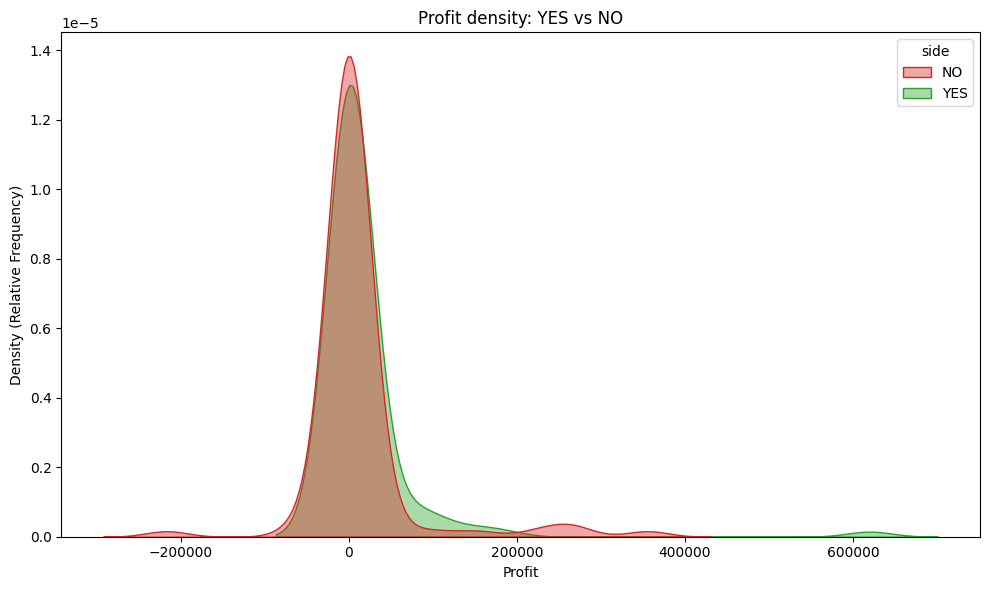

In [63]:
plt.figure(figsize=(10, 6))

# 3. Generate the overlapping KDE (Kernel Density Estimate) plot
# common_norm=False ensures both curves are scaled independently. 
# Without it, if there are 10x more YES trades than NO trades, the NO curve would look completely flat.
sns.kdeplot(
    data=df_trader_profit, 
    x='profit', 
    hue='side', 
    fill=True, 
    alpha=0.4, 
    palette={'YES': '#2ca02c', 'NO': '#d62728'},
    common_norm=False
)

# 4. Add labels and title
plt.title('Profit density: YES vs NO')
plt.xlabel('Profit')
plt.ylabel('Density (Relative Frequency)')

# 5. Clean up layout and display
plt.tight_layout()
plt.show()

In [73]:
df_ai = pd.read_csv("ai_classified_tyler_trades_full.csv")

,date,trade_type,side,outcome,amount,price,total,title,user,ai_prompt,ai_guess
0,2026-07-04 16:28:00,TRADE,BUY,No,3411.910000,0.360000,1228.287600,US-Iran 60 day negotiation period extended?,0xe4de861d59e174d3d153a5968bc122c66f30c949,\nYou are an expert in text interpretation and...,usa_iran_conflict
1,2026-07-04 16:19:00,TRADE,BUY,No,426.130000,0.639695,272.593200,Strait of Hormuz traffic returns to normal by ...,0xe4de861d59e174d3d153a5968bc122c66f30c949,\nYou are an expert in text interpretation and...,usa_iran_conflict
2,2026-07-04 16:18:00,TRADE,BUY,No,5000.000000,0.485876,2429.378600,Strait of Hormuz traffic returns to normal by ...,0xe4de861d59e174d3d153a5968bc122c66f30c949,\nYou are an expert in text interpretation and...,usa_iran_conflict
3,2026-07-04 16:17:00,TRADE,BUY,No,15.880000,0.630000,10.004400,Strait of Hormuz traffic returns to normal by ...,0xe4de861d59e174d3d153a5968bc122c66f30c949,\nYou are an expert in text interpretation and...,usa_iran_conflict
4,2026-07-04 16:17:00,TRADE,BUY,No,1603.980000,0.630000,1010.507400,Strait of Hormuz traffic returns to normal by ...,0xe4de861d59e174d3d153a5968bc122c66f30c949,\nYou are an expert in text interpretation and...,usa_iran_conflict
...,...,...,...,...,...,...,...,...,...,...,...
35195,2026-07-01 13:23:00,TRADE,BUY,Yes,17.241378,0.290000,4.999999,Will England win on 2026-07-01?,0x483b6886d4b9451484e9a43db673efc56f262fc8,\nYou are an expert in text interpretation and...,API_ERROR
35196,2026-06-30 17:31:00,TRADE,BUY,Yes,13.888885,0.720000,9.999997,Will France win on 2026-06-30?,0x483b6886d4b9451484e9a43db673efc56f262fc8,\nYou are an expert in text interpretation and...,API_ERROR
35197,2026-06-29 04:38:00,TRADE,BUY,Yes,45.454544,0.440000,19.999999,Tyler Robinson convicted of homicide?,0x483b6886d4b9451484e9a43db673efc56f262fc8,\nYou are an expert in text interpretation and...,API_ERROR
35198,2026-06-27 18:18:00,TRADE,BUY,Yes,14.925372,0.670000,9.999999,Will England win on 2026-06-27?,0x483b6886d4b9451484e9a43db673efc56f262fc8,\nYou are an expert in text interpretation and...,API_ERROR


In [103]:
#Just making sure that we only have purchases in the df.
df_ai.value_counts("side")

side
BUY    35200
Name: count, dtype: int64

In [75]:
print((df_ai["ai_guess"] == "API_ERROR").sum())
print(len(df_ai))

7816
35200


In [84]:
#For some reason we got 7816 API errors... Let's remove them
df_ai_clean = df_ai[df_ai["ai_guess"] != "API_ERROR"]
print((df_ai_clean["ai_guess"] == "API_ERROR").sum())
print(len(df_ai_clean))

0
27384


In [100]:
df_ai_clean

,date,trade_type,side,outcome,amount,price,total,title,user,ai_prompt,ai_guess
0,2026-07-04 16:28:00,TRADE,BUY,No,3411.910000,0.360000,1228.287600,US-Iran 60 day negotiation period extended?,0xe4de861d59e174d3d153a5968bc122c66f30c949,\nYou are an expert in text interpretation and...,usa_iran_conflict
1,2026-07-04 16:19:00,TRADE,BUY,No,426.130000,0.639695,272.593200,Strait of Hormuz traffic returns to normal by ...,0xe4de861d59e174d3d153a5968bc122c66f30c949,\nYou are an expert in text interpretation and...,usa_iran_conflict
2,2026-07-04 16:18:00,TRADE,BUY,No,5000.000000,0.485876,2429.378600,Strait of Hormuz traffic returns to normal by ...,0xe4de861d59e174d3d153a5968bc122c66f30c949,\nYou are an expert in text interpretation and...,usa_iran_conflict
3,2026-07-04 16:17:00,TRADE,BUY,No,15.880000,0.630000,10.004400,Strait of Hormuz traffic returns to normal by ...,0xe4de861d59e174d3d153a5968bc122c66f30c949,\nYou are an expert in text interpretation and...,usa_iran_conflict
4,2026-07-04 16:17:00,TRADE,BUY,No,1603.980000,0.630000,1010.507400,Strait of Hormuz traffic returns to normal by ...,0xe4de861d59e174d3d153a5968bc122c66f30c949,\nYou are an expert in text interpretation and...,usa_iran_conflict
...,...,...,...,...,...,...,...,...,...,...,...
27379,2026-06-28 15:26:00,TRADE,BUY,Yes,6.060605,0.330000,1.999999,Will South Africa vs. Canada end in a draw?,0xb1a19b87236e92c2eaaf20c5f2cd30a94167a41e,\nYou are an expert in text interpretation and...,sports
27380,2026-06-28 14:03:00,TRADE,BUY,Yes,9.610000,0.130000,1.249300,Will the highest temperature in Warsaw be 39°C...,0xb1a19b87236e92c2eaaf20c5f2cd30a94167a41e,\nYou are an expert in text interpretation and...,other
27381,2026-06-28 13:58:00,TRADE,BUY,Yes,21.545400,0.010000,0.215454,Will the highest temperature in Warsaw be 41°C...,0xb1a19b87236e92c2eaaf20c5f2cd30a94167a41e,\nYou are an expert in text interpretation and...,other
27382,2026-06-28 13:58:00,TRADE,BUY,Yes,13.470000,0.055000,0.740850,Will the highest temperature in Warsaw be 40°C...,0xb1a19b87236e92c2eaaf20c5f2cd30a94167a41e,\nYou are an expert in text interpretation and...,other


In [81]:
#Now we can get the different categories
chart_ai_guess = df_ai_clean["ai_guess"].value_counts()

In [92]:
chart_ai_guess = pd.DataFrame(chart_ai_guess)

Index(['count'], dtype='str')

In [97]:
chart_ai_guess = chart_ai_guess.reset_index()
chart_ai_guess["percentage"] = (chart_ai_guess["count"] / chart_ai_guess["count"].sum()) * 100

,ai_guess,count,percentage
0,sports,6609,24.134531
1,elections_global_and_domestic,4636,16.929594
2,usa_iran_conflict,4069,14.859042
3,tech,2451,8.950482
4,crypto_currencies,2247,8.205521
5,political_issues_except_us_elections,1838,6.711949
6,pop_culture_and_entertainment,1732,6.324861
7,other,1218,4.447853
8,geopolitics_except_elections,1173,4.283523
9,crime,496,1.811277


In [98]:
chart_ai_guess.to_csv("chart_ai_guess_w_perc.csv")

In [83]:
chart_ai_guess.to_csv("chart_ai_guess.csv")

In [107]:
#We create an additoinal column with all the money spent on the different bet categories
ai_money_bet = df_ai_clean.groupby("ai_guess").agg(
    total_bets=("ai_guess", "count"),
    total_money=("total", "sum")
).reset_index()
ai_money_bet["percentage of bets"] = chart_ai_guess["percentage"]
ai_money_bet["percentage of USD"] = (ai_money_bet["total_money"] / ai_money_bet["total_money"].sum()) * 100

In [109]:
ai_money_bet.to_csv("ai_guess_w_money.csv")

In [85]:
df_pop_bets = pd.read_csv("10_most_pop_bets.csv")
df_pop_bets

,title,count
0,Will Alex Bores win the NY-12 Democratic Prima...,540
1,Will the U.S. invade Iran before 2027?,489
2,Will Ronaldo Cry at the World Cup?,456
3,Tyler Robinson convicted of homicide?,364
4,Will Google have the best AI model at the end ...,307
5,Will the Liberal Democratic Party of Russia (L...,304
6,Will Uhlsport be the brand of gloves worn by t...,236
7,Will OpenAI release a new frontier model on or...,197
8,Will Pope Leo XIV be TIME's Person of the Year...,188
9,Will Alex Bores win the NY-12 Democratic Prima...,183
